External Evaluation For SEEG and Gene expression Datasets across all methods

In [ ]:
!touch /content/utils/__init__.py


In [ ]:
import importlib.util
import sys

utils_path = '/content/utils/utils.py'

module_name = 'utils.utils'

spec = importlib.util.spec_from_file_location(module_name, utils_path)
utils = importlib.util.module_from_spec(spec)
sys.modules[module_name] = utils
spec.loader.exec_module(utils)

methods = utils.load_interpolation_methods()
print("Loaded Interpolation Methods:")
for method_name in methods:
    print(" →", method_name)


✅ Loaded Interpolation Methods:
 → Exponential_Interpolation
 → KNN_Interpolation
 → Linear_Interpolation
 → MLP_Interpolation
 → Polynomial_Interpolation
 → Spline_Interpolation


In [ ]:
import sys
sys.path.append('/content')

from utils.utils import load_interpolation_methods

methods = load_interpolation_methods()
print("Loaded Interpolation Methods:")
for method_name in methods:
    print(" →", method_name)


✅ Loaded Interpolation Methods:
 → Exponential_Interpolation
 → KNN_Interpolation
 → Linear_Interpolation
 → MLP_Interpolation
 → Polynomial_Interpolation
 → Spline_Interpolation


In [ ]:
!mkdir -p interpolation_methods metrics plots main utils
!touch utils/__init__.py
!touch interpolation_methods/__init__.py
!touch metrics/__init__.py
!touch plots/__init__.py

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
sys.path.append('/content')

In [ ]:
!ls /content/drive/MyDrive/data/seeg

band_powers.npy  coords.npy  load_plot_seeg.ipynb


In [ ]:
%%writefile utils/utils.py

import numpy as np
from sklearn.model_selection import KFold
import importlib
import pkgutil
import sys
import os

# Ensure the parent directory and interpolation_methods are in the Python path
sys.path.append('/content/')
sys.path.append('/content/interpolation_methods')

def create_grid_from_coords(coords, num_points):
    """
    Creates a grid covering the bounding box of the provided coordinates
    The coordinates will be the same for every one but the number of points can vary depending on the method

    Parameters:
    - coords: array of shape (n_samples, 3) with [x, y, z] coordinates
    - num_points: number of grid points per axis (resolution)

    Returns:
    - grid_x, grid_y, grid_z: arrays defining the grid (used for plotting)
    """
    min_x, max_x = np.min(coords[:, 0]), np.max(coords[:, 0])
    min_y, max_y = np.min(coords[:, 1]), np.max(coords[:, 1])
    min_z, max_z = np.min(coords[:, 2]), np.max(coords[:, 2])

    grid_x = np.linspace(min_x, max_x, num_points)
    grid_y = np.linspace(min_y, max_y, num_points)
    grid_z = np.linspace(min_z, max_z, num_points)
    return grid_x, grid_y, grid_z

def run_cross_validation(interpolator_func, coords, band_values, grid, num_folds=10):
    from metrics.metrics import calculate_metrics
    from sklearn.model_selection import KFold
    kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
    cv_metrics = []
    cv_timings = []

    for train_index, test_index in kf.split(coords):
        train_coords = coords[train_index]
        train_values = band_values[train_index]
        test_coords = coords[test_index]
        test_values = band_values[test_index]

        # Call the interpolation function
        predicted_values, duration = interpolator_func(train_coords, train_values, test_coords, timing=True)

        # Filter out NaN values from the predicted values and corresponding test values
        valid_indices = ~np.isnan(predicted_values)
        predicted_values = predicted_values[valid_indices]
        filtered_test_values = test_values[valid_indices]

        # Check if there are any valid predictions left
        if len(predicted_values) == 0:
            print(f"Warning: No valid predictions for method {interpolator_func.__name__}. Skipping this fold.")
            continue

        # Calculate metrics only for valid predictions
        scores = calculate_metrics(predicted_values, filtered_test_values)
        cv_timings.append(duration)
        cv_metrics.append(scores)

    return cv_metrics, cv_timings


def load_interpolation_methods():
    """
    Dynamically loads all interpolation functions from the interpolation_methods folder.
    Only loads functions that contain 'interpolation' in their name.
    Returns a dictionary with function names as keys and function objects as values.
    """
    methods = {}
    package_name = "interpolation_methods"

    # Dynamically import the interpolation_methods package
    try:
        import interpolation_methods
    except ModuleNotFoundError:
        print(f"Module '{package_name}' not found.")
        return methods

    for importer, modname, ispkg in pkgutil.iter_modules(interpolation_methods.__path__):
        try:
            module = importlib.import_module(f"{package_name}.{modname}")
            for attr in dir(module):
                func = getattr(module, attr)
                if callable(func) and "interpolation" in attr.lower():
                    methods[attr] = func
        except Exception as e:
            print(f"Error loading module '{modname}': {e}")
    return methods



Overwriting utils/utils.py


In [ ]:
!ls /content/utils/utils.py


/content/utils/utils.py


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Checking if the modules are loaded correctly
from utils.utils import load_interpolation_methods

methods = load_interpolation_methods()
print("Loaded Interpolation Methods:")
for method_name in methods:
    print(method_name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded Interpolation Methods:
Exponential_Interpolation
KNN_Interpolation
Linear_Interpolation
MLP_Interpolation
Polynomial_Interpolation
Spline_Interpolation


In [ ]:
%%writefile plots/plots.py

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D plots
from utils.utils import create_grid_from_coords
#======================================3D Visualisation===============================
def plot_3d(original_coords, original_values, predicted_values, vmin, vmax, method, grid=None, num_points=None):
  """
  Creates a 3D visualisation comparing original sparse data and interpolated volume

  Parameters:
  - original_coords: array of shape (n_samples, 3) with [x, y, z] coordinates
  - original_values: array of shape (n_samples, ) of values (e.g., power estimates) for each coordinate
  - predicted_values: 3D array of shape (n_points, n_points, n_points) with interpolated values
  - vmin,vmax: colour limits for plotting
  - method_name: string indicating the interpolation method to plot
  - grid: Optional tuple or calling function in utils
  """
  if grid is None:
    grid_x, grid_y, grid_z = create_grid_from_coords(original_coords, num_points)
  else:
    grid_x, grid_y, grid_z = grid

  #Create a mesh gid for the interpolation grid
  X, Y, Z = np.meshgrid(grid_x, grid_y, grid_z, indexing='ij')

  # Downsample the grid and interpolated volume for visualization
  step = 4  # adjust this as needed
  X_sample = X[::step, ::step, ::step].flatten()
  Y_sample = Y[::step, ::step, ::step].flatten()
  Z_sample = Z[::step, ::step, ::step].flatten()
  values_sample = predicted_values[::step, ::step, ::step].flatten()

  fig = plt.figure(figsize=(12, 6))

  # Subplot 1: Original sparse data in 3D
  ax1 = fig.add_subplot(121, projection='3d')
  p1 = ax1.scatter(original_coords[:, 0], original_coords[:, 1], original_coords[:, 2],
                    c=original_values, cmap='turbo', vmin=vmin, vmax=vmax)
  ax1.set_title("Original SEEG Data")
  ax1.set_xlabel("X")
  ax1.set_ylabel("Y")
  ax1.set_zlabel("Z")
  fig.colorbar(p1, ax=ax1, shrink=0.5)

  # Subplot 2: 3D downsampled interpolated data
  ax2 = fig.add_subplot(122, projection='3d')
  p2 = ax2.scatter(X_sample, Y_sample, Z_sample,
                    c=values_sample, cmap='turbo', vmin=vmin, vmax=vmax)
  ax2.set_title(f"3D Interpolated Data ({method})")
  ax2.set_xlabel("X")
  ax2.set_ylabel("Y")
  ax2.set_zlabel("Z")
  fig.colorbar(p2, ax=ax2, shrink=0.5)

  plt.tight_layout()
  plt.show()

#======================================2D Visualisation========================================
def plot_2d_slice(original_coords, original_values, predicted_values, vmin, vmax, method, grid=None):
    """
    Plots a 2D comparison of the original data and interpolated results for the middle z-slice.

    Parameters:
      - original_coords: (n, 3) array of original coordinates.
      - original_values: (n,) array of values for each coordinate.
      - interpolated_volume: 3D array of interpolated values (shape: [nz, ny, nx]).
      - vmin, vmax: Color limits.
      - method_name: Name of the interpolation method.
      - grid: Optional tuple (grid_x, grid_y, grid_z). If None, the grid is computed from original_coords.
    """
    if grid is None:
        grid_x, grid_y, grid_z = create_grid_from_coords(original_coords)
    else:
        grid_x, grid_y, grid_z = grid

    # Determine the middle slice index and corresponding z value
    mid_idx = predicted_values.shape[0] // 2
    mid_z = grid_z[len(grid_z) // 2]

    # Filter the original data to only include points near the middle z value.
    tolerance = (grid_z[1] - grid_z[0]) / 2
    indices = np.where(np.abs(original_coords[:, 2] - mid_z) < tolerance)[0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Plot original data for the middle slice
    sc = ax1.scatter(original_coords[indices, 0], original_coords[indices, 1],
                     c=original_values[indices], cmap='turbo', vmin=vmin, vmax=vmax)
    ax1.set_title(f"Original Data (z ≈ {mid_z:.2f})")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    plt.colorbar(sc, ax=ax1, label="Power Estimate")

    # Plot the 2D interpolated slice from the volume
    im = ax2.imshow(predicted_values[mid_idx, :, :],
                    extent=(np.min(grid_x), np.max(grid_x),
                            np.min(grid_y), np.max(grid_y)),
                    origin='lower', cmap='turbo', vmin=vmin, vmax=vmax)
    ax2.set_title(f"2D Interpolated Slice ({method})")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    plt.colorbar(im, ax=ax2, label="Interpolated Value")

    plt.tight_layout()
    plt.show()


Overwriting plots/plots.py


In [ ]:
%%writefile interpolation_methods/interpolation_methods.py
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from numpy.polynomial.chebyshev import Chebyshev
from scipy.interpolate import griddata, Rbf
import numpy as np
import time
from pykrige.ok3d import OrdinaryKriging3D

# ---------------------------- Exponential Kriging ----------------------------
def Exponential_Interpolation(coords, values, new_coords, timing=False):
    start_time = time.time()
    x_new, y_new, z_new = new_coords[:, 0], new_coords[:, 1], new_coords[:, 2]
    OK = OrdinaryKriging3D(
        coords[:, 0], coords[:, 1], coords[:, 2],
        values, variogram_model='exponential',
        verbose=False, enable_plotting=False
    )
    predicted_values, _ = OK.execute('points', x_new.tolist(), y_new.tolist(), z_new.tolist())
    duration = time.time() - start_time
    return (np.array(predicted_values), duration) if timing else np.array(predicted_values)

# ---------------------------- Linear Interpolation ----------------------------
def Linear_Interpolation(coords, values, new_coords, timing=False):
    start_time = time.time()
    predicted_values = griddata(coords, values, new_coords, method='linear')
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# ---------------------------- KNN Interpolation ----------------------------
def KNN_Interpolation(coords, values, new_coords, timing=False):
    start_time = time.time()
    model = KNeighborsRegressor(n_neighbors=5, weights='distance')
    model.fit(coords, values)
    predicted_values = model.predict(new_coords)
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# ---------------------------- Spline Interpolation ----------------------------
def Spline_Interpolation(coords, values, new_coords, timing=False, smooth=0.2):
    start_time = time.time()
    x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
    new_x, new_y, new_z = new_coords[:, 0], new_coords[:, 1], new_coords[:, 2]
    interpolator = Rbf(x, y, z, values, function='multiquadric', smooth=smooth)
    predicted_values = interpolator(new_x, new_y, new_z)
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# ---------------------------- Polynomial Interpolation ----------------------------
def Polynomial_Interpolation(coords, values, new_coords, timing=False):
    start_time = time.time()
    x_train = coords[:, 0]
    cheb = Chebyshev.fit(x_train, values, deg=2)
    interpolated_values = cheb(new_coords[:, 0])
    duration = time.time() - start_time
    return (interpolated_values, duration) if timing else interpolated_values

# ---------------------------- MLP Interpolation ----------------------------
def MLP_Interpolation(coords, values, new_coords, timing=False):
    start_time = time.time()
    model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
    model.fit(coords, values)
    interpolated_values = model.predict(new_coords)
    duration = time.time() - start_time
    return (interpolated_values, duration) if timing else interpolated_values

# ---------------------------- Helper Function ----------------------------
def get_interpolator_by_name(method_name):
    method_map = {
        'Exponential_Interpolation': Exponential_Interpolation,
        'Linear_Interpolation': Linear_Interpolation,
        'KNN_Interpolation': KNN_Interpolation,
        'Spline_Interpolation': Spline_Interpolation,
        'Polynomial_Interpolation': Polynomial_Interpolation,
        'MLP_Interpolation': MLP_Interpolation
    }
    return method_map.get(method_name, None)




Overwriting interpolation_methods/interpolation_methods.py


EXTERNAL EVALUATION - SEEG DATASET

In [ ]:
%%writefile main/main.py
import sys

# Ensure the parent directory is in the Python path
sys.path.append('/content')
sys.path.append('/content/metrics')
sys.path.append('/content/utils')
sys.path.append('/content/plots')
sys.path.append('/content/interpolation_methods')

try:
    from pykrige.ok3d import OrdinaryKriging3D
except ImportError:
    os.system('pip install pykrige')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykrige.ok3d import OrdinaryKriging3D

# Imports from custom modules
from utils.utils import create_grid_from_coords, run_cross_validation, load_interpolation_methods
from metrics.metrics import calculate_metrics, extracted_interpolated_values
from plots.plots import plot_3d, plot_2d_slice

#EXTERNAL EVALUATION

# Load the SEEG data
file_path = '/content/drive/MyDrive/data/seeg'
coords = np.load(os.path.join(file_path, 'coords.npy'))
band_powers = np.load(os.path.join(file_path, 'band_powers.npy'), allow_pickle=True).item()

# Choose a frequency band (can loop over multiple)
band = 'Delta'
band_values = np.array(band_powers[band])
vmin = np.min(band_values)
vmax = np.max(band_values)

# Create the 3D grid
grid_x, grid_y, grid_z = create_grid_from_coords(coords, num_points=40)

# Dynamically load interpolation methods
from interpolation_methods.interpolation_methods import (
    Spline_Interpolation,
    KNN_Interpolation,
    Linear_Interpolation,
    Polynomial_Interpolation,
    Exponential_Interpolation,
    MLP_Interpolation
)

methods = {
    'Spline_Interpolation': Spline_Interpolation,
    'KNN_Interpolation': KNN_Interpolation,
    'Linear_Interpolation': Linear_Interpolation,
    'Polynomial_Interpolation': Polynomial_Interpolation,
    'Exponential_Interpolation': Exponential_Interpolation,
    'MLP_Interpolation': MLP_Interpolation,
}

# Dictionary to store results
all_results = {}

# Cross-validation for each method
for method_name, method_func in methods.items():
    print(f"\nRunning cross-validation for {method_name}...")

    # Run cross-validation and collect metrics + timing
    cv_metrics, cv_timings = run_cross_validation(
        method_func,
        coords,
        band_values,
        grid=(grid_x, grid_y, grid_z)
    )

    # Save results for this method
    df_cv = pd.DataFrame(cv_metrics)
    df_cv['Time (sec)'] = cv_timings
    all_results[method_name] = df_cv

    print(f"Results for {method_name}:")
    print(df_cv)

# Plotting the comparison scatter plot for each metric
metrics_list = ['MSE', 'MAE', 'RMSE', 'R²']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['blue', 'red', 'green', 'purple', 'orange', 'cyan']
method_names = list(methods.keys())

for i, metric in enumerate(metrics_list):
    for j, method_name in enumerate(method_names):
        df_cv = all_results[method_name]
        if metric in df_cv.columns:
            # Add small x-jitter for better separation
            jitter = np.random.normal(0, 0.05, size=len(df_cv))
            x_vals = np.full(len(df_cv), j) + jitter
            axes[i].scatter(
                x_vals,
                df_cv[metric],
                color=colors[j % len(colors)],
                s=30,
                alpha=0.8
            )

    axes[i].set_title(f"{metric} Comparison", fontsize=12)
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(range(len(method_names)))
    axes[i].set_xticklabels(method_names, rotation=45, ha='right')
    axes[i].grid(True)

    if metric == 'R²':
        axes[i].set_ylim(-4.5, 1.0)  # Expand to show MLP

# Legend (consistent colour mapping)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=method, markerfacecolor=color, markersize=8)
    for method, color in zip(method_names, colors)
]
axes[0].legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1.0))

plt.tight_layout()
plt.savefig('/content/metrics_comparison_clean.png')
plt.show()



Overwriting main/main.py


In [ ]:
%%writefile metrics/metrics.py
#This creates the .py file

# Whatever is under this will be loaded into the metrics.py
#To call this in the main.py file w ehave to import metrics.metrics.py

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def extracted_interpolated_values(OK_obj, x_coords, y_coords, z_coords):
    """
    Extracts interpolated values at provided coordinates using the given kriging object.

    Parameters:
      - OK_obj: An OrdinaryKriging3D object.
      - x_coords, y_coords, z_coords: Arrays of coordinates.

    Returns:
      - Array of predicted values.
    """
    predicted_values = []
    for i in range(len(x_coords)):
        val, _ = OK_obj.execute('points', [x_coords[i]], [y_coords[i]], [z_coords[i]])
        predicted_values.append(val[0])
    return np.array(predicted_values)

def calculate_metrics(predicted_values, test_values, metric=None):
    """
    Compute evaluation metrics to evaluate interpoaltion performance
    Parameters:
      - pred_values: numpy array of predicted values
      - test_values: numpy array of ground truth values for comparison
      - metrics (list): list of metrics to compute
    Returns:
      - scores (dict): A dictionary with the computed metric scores.
    """
    mse = mean_squared_error(test_values, predicted_values)
    mae = mean_absolute_error(test_values, predicted_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(test_values, predicted_values)
    scores = {"MSE": mse, "MAE": mae, "RMSE": rmse, "R²": r2}
    return scores


Overwriting metrics/metrics.py


In [ ]:
!python main/main.py



Running cross-validation for Spline_Interpolation...
Results for Spline_Interpolation:
        MSE       MAE      RMSE        R²  Time (sec)
0  0.002921  0.044693  0.054049  0.376109    0.199325
1  0.003218  0.045398  0.056726  0.395660    0.157786
2  0.002862  0.042939  0.053502  0.461549    0.162408
3  0.002527  0.041153  0.050271  0.399342    0.153836
4  0.003081  0.042831  0.055506  0.348803    0.147639
5  0.002871  0.043109  0.053584  0.412184    0.146670
6  0.002828  0.041049  0.053180  0.443420    0.148748
7  0.002790  0.042540  0.052822  0.454897    0.164736
8  0.003659  0.045924  0.060490  0.073275    0.145397
9  0.003067  0.042607  0.055382  0.344913    0.149449

Running cross-validation for KNN_Interpolation...
Results for KNN_Interpolation:
        MSE       MAE      RMSE        R²  Time (sec)
0  0.003029  0.045313  0.055038  0.353066    0.004535
1  0.003149  0.044298  0.056118  0.408527    0.003007
2  0.003018  0.043625  0.054937  0.432276    0.002936
3  0.002656  0.04205

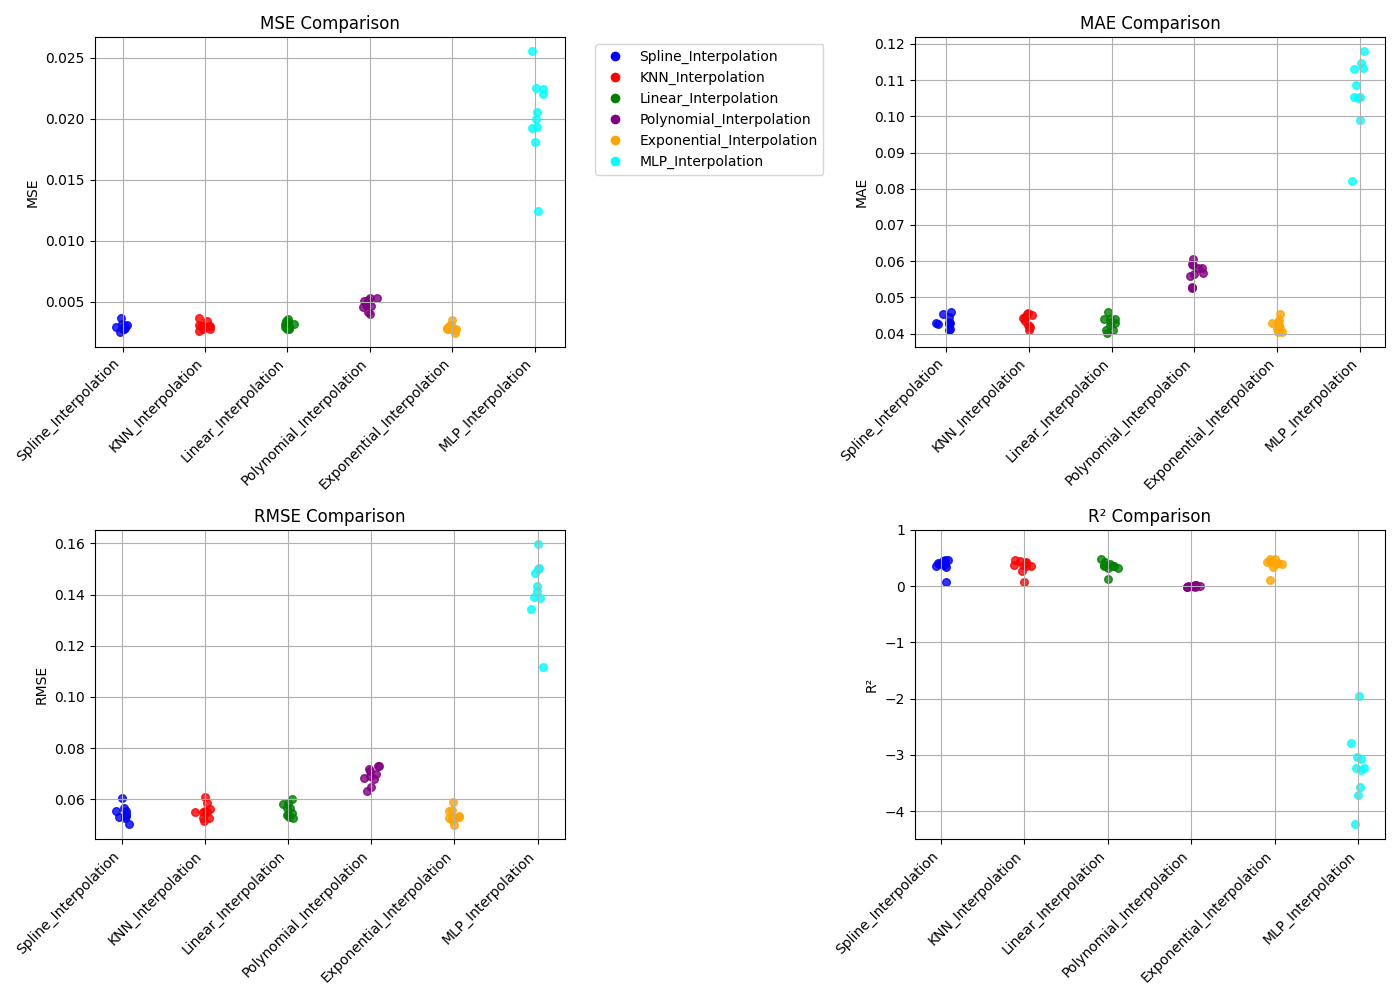

In [ ]:
from IPython.display import Image, display

# Display the saved plot
display(Image(filename='/content/metrics_comparison_clean.png'))



In [ ]:
!ls /content/interpolation_methods/interpolation_methods.py


/content/interpolation_methods/interpolation_methods.py


In [ ]:
import importlib.util

# Load interpolation_methods/interpolation_methods.py manually
interp_path = '/content/interpolation_methods/interpolation_methods.py'
spec = importlib.util.spec_from_file_location("interpolation_methods.interpolation_methods", interp_path)
interp_module = importlib.util.module_from_spec(spec)
sys.modules["interpolation_methods.interpolation_methods"] = interp_module
spec.loader.exec_module(interp_module)

print("Available Interpolation Functions:")
print([fn for fn in dir(interp_module) if 'interpolation' in fn.lower()])


✅ Available Interpolation Functions:
['Exponential_Interpolation', 'KNN_Interpolation', 'Linear_Interpolation', 'MLP_Interpolation', 'Polynomial_Interpolation', 'Spline_Interpolation']


EXTERNAL EVALUATION - GENE EXPRESSION DATA SET


Processing gene: GRIA1
 → Spline_Interpolation
 → KNN_Interpolation
 → Linear_Interpolation
 → Polynomial_Interpolation
 → Exponential_Interpolation
 → MLP_Interpolation

Average Metrics Across Genes:

Spline_Interpolation:
MSE     0.429376
MAE     0.506487
RMSE    0.654057
R²      0.563551
dtype: float64

KNN_Interpolation:
MSE     0.458389
MAE     0.518549
RMSE    0.676126
R²      0.533900
dtype: float64

Linear_Interpolation:
MSE     0.504960
MAE     0.546757
RMSE    0.709577
R²      0.501195
dtype: float64

Polynomial_Interpolation:
MSE     1.001540
MAE     0.787070
RMSE    0.999226
R²     -0.009813
dtype: float64

Exponential_Interpolation:
MSE     0.463729
MAE     0.524423
RMSE    0.680318
R²      0.528649
dtype: float64

MLP_Interpolation:
MSE     0.524368
MAE     0.562654
RMSE    0.723116
R²      0.467074
dtype: float64


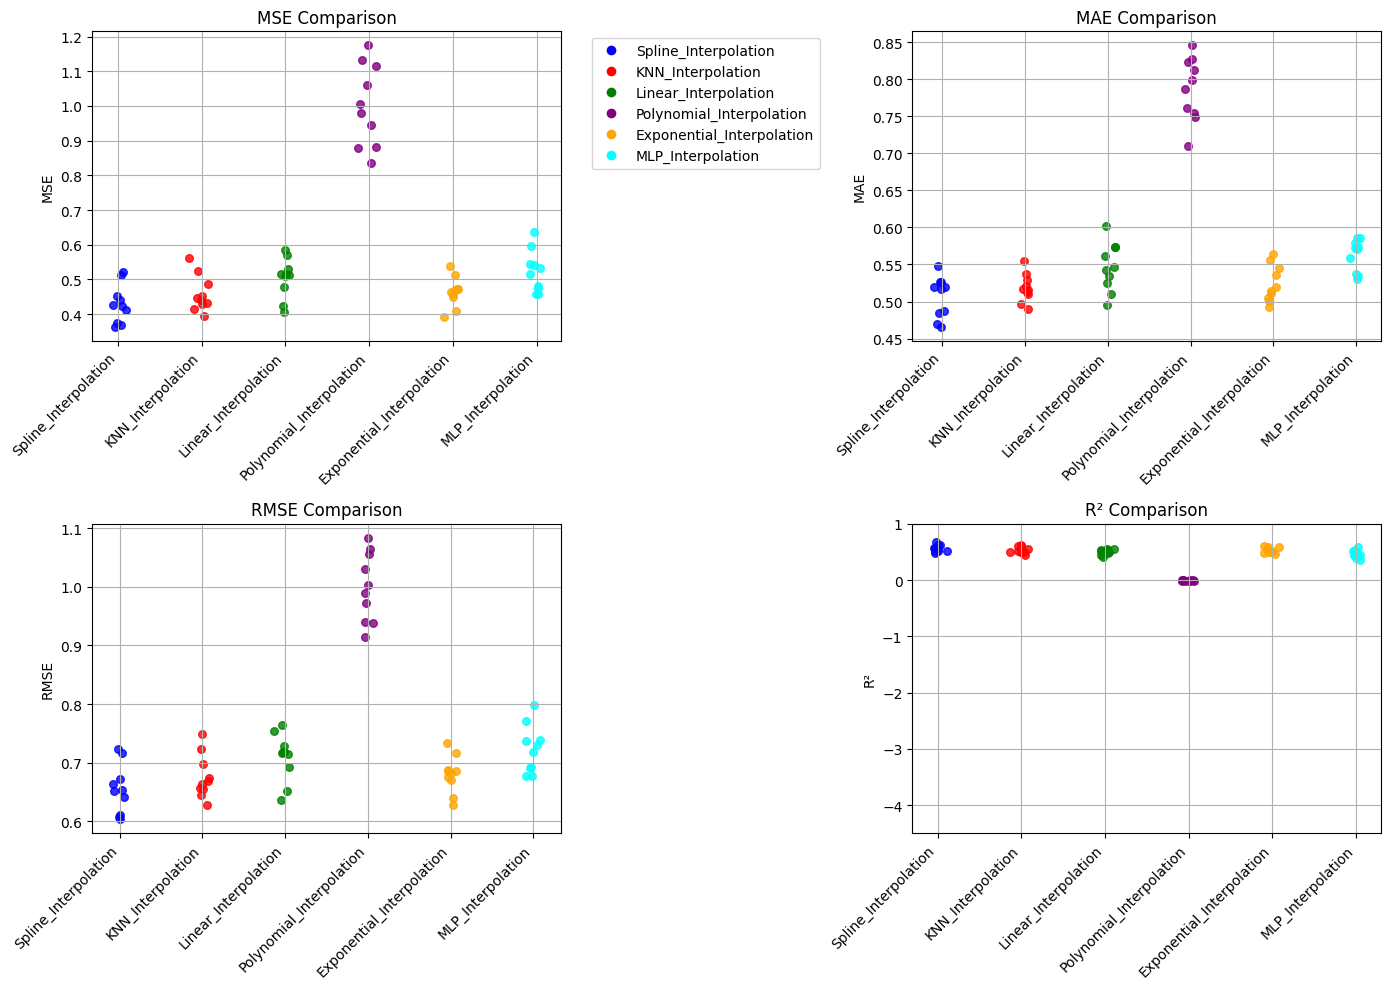

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
sys.path.append('/content')
sys.path.append('/content/metrics')
sys.path.append('/content/utils')
sys.path.append('/content/plots')
sys.path.append('/content/interpolation_methods')

# Imports
from utils.utils import create_grid_from_coords, run_cross_validation
from interpolation_methods.interpolation_methods import (
    Spline_Interpolation,
    KNN_Interpolation,
    Linear_Interpolation,
    Polynomial_Interpolation,
    Exponential_Interpolation,
    MLP_Interpolation
)

# Load gene expression data
data_path = '/content/drive/MyDrive/data/gene_expression'
expression_coords = np.load(os.path.join(data_path, 'expression_coords.npy'))
expression_data = np.load(os.path.join(data_path, 'expression.npy'), allow_pickle=True).item()

# Create grid from coordinates
grid_x, grid_y, grid_z = create_grid_from_coords(expression_coords, num_points=30)

# Methods to compare
methods = {
    'Spline_Interpolation': Spline_Interpolation,
    'KNN_Interpolation': KNN_Interpolation,
    'Linear_Interpolation': Linear_Interpolation,
    'Polynomial_Interpolation': Polynomial_Interpolation,
    'Exponential_Interpolation': Exponential_Interpolation,
    'MLP_Interpolation': MLP_Interpolation,
}

gene = "GRIA1"
values = np.array(expression_data[gene])


# Dictionary to store results
all_results = {method: [] for method in methods}

# Evaluate each method on the selected gene
print(f"\nProcessing gene: {gene}")
for method_name, method_func in methods.items():
    print(f" → {method_name}")
    cv_metrics, _ = run_cross_validation(
        method_func,
        expression_coords,
        values,
        grid=(grid_x, grid_y, grid_z)
    )
    all_results[method_name].extend(cv_metrics)

# Convert to DataFrames
avg_results = {
    method: pd.DataFrame(results).mean() for method, results in all_results.items()
}
print("\nAverage Metrics Across Genes:")
for method, avg in avg_results.items():
    print(f"\n{method}:\n{avg}")

# Plot
metrics_list = ['MSE', 'MAE', 'RMSE', 'R²']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['blue', 'red', 'green', 'purple', 'orange', 'cyan']
method_names = list(methods.keys())

for i, metric in enumerate(metrics_list):
    for j, method_name in enumerate(method_names):
        df = pd.DataFrame(all_results[method_name])
        if metric in df.columns:
            jitter = np.random.normal(0, 0.05, size=len(df))
            x_vals = np.full(len(df), j) + jitter
            axes[i].scatter(
                x_vals,
                df[metric],
                color=colors[j % len(colors)],
                s=30,
                alpha=0.8
            )

    axes[i].set_title(f"{metric} Comparison", fontsize=12)
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(range(len(method_names)))
    axes[i].set_xticklabels(method_names, rotation=45, ha='right')
    axes[i].grid(True)

    if metric == 'R²':
        axes[i].set_ylim(-4.5, 1.0)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=method, markerfacecolor=color, markersize=8)
    for method, color in zip(method_names, colors)
]
axes[0].legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1.0))

plt.tight_layout()
plt.savefig('/content/gene_metrics_comparison.png')
plt.show()
